In [1]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
class DotDataset(Dataset):
    def __init__(self, num_images=1000, size=100, dot_size=2, dot_min=5, dot_max=10):
        self.num_images = num_images
        self.size = size
        self.dot_size = dot_size
        self.dot_min = dot_min
        self.dot_max = dot_max
        
    def __len__(self):
        return self.num_images
    
    def __getitem__(self, idx):
        img = np.zeros((self.size, self.size), dtype=np.float32)
        labels = []  
        
        num_dots = np.random.randint(self.dot_min, self.dot_max)
        
        for _ in range(num_dots):
            x = np.random.randint(0, self.size - self.dot_size)
            y = np.random.randint(0, self.size - self.dot_size)
            
            img[y:y+self.dot_size, x:x+self.dot_size] = 1.0
            cx = (x + self.dot_size/2) / self.size
            cy = (y + self.dot_size/2) / self.size
            w = self.dot_size / self.size
            h = self.dot_size / self.size
            labels.append([cx, cy, w, h])
            
        img_tensor = torch.tensor(img, dtype=torch.float32).unsqueeze(0)  
        return img_tensor, torch.tensor(labels, dtype=torch.float32)

In [3]:
def custom_collate(batch):
    images = torch.stack([item[0] for item in batch])  
    targets = [item[1] for item in batch]  
    return images, targets
    
train_dataset = DotDataset(num_images=2000)
val_dataset = DotDataset(num_images=100)

train_loader = DataLoader(train_dataset,
                          batch_size=32,
                          shuffle=True,
                          collate_fn=custom_collate)

val_loader = DataLoader(val_dataset,
                        batch_size=32,
                        shuffle=False,
                        collate_fn=custom_collate)

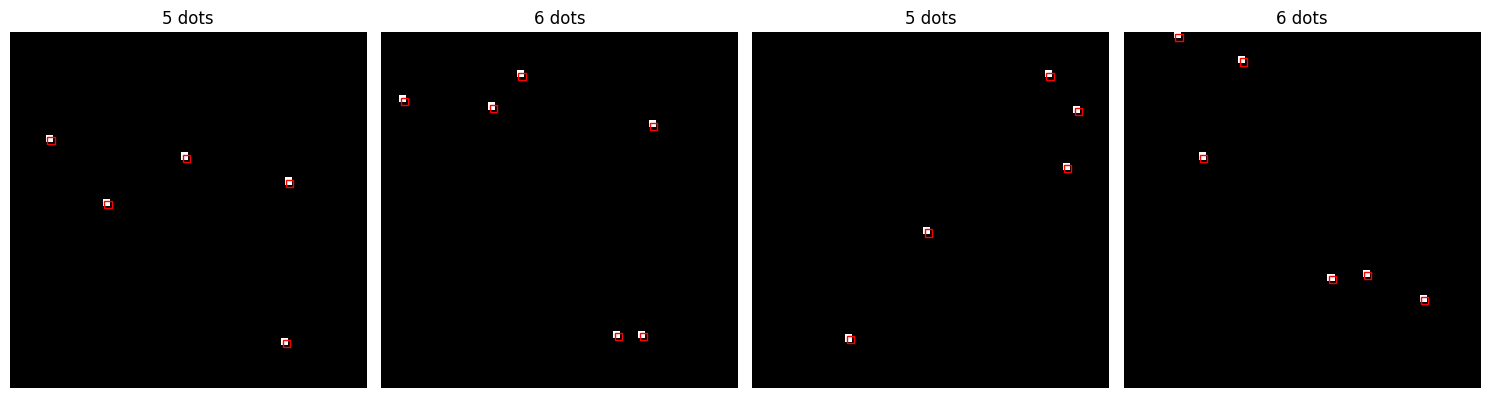

In [4]:
images, targets = next(iter(train_loader))
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

if len(images) == 1:
    axes = [axes]
for i in range(len(axes)):
    img = images[i, 0].cpu().numpy()
    axes[i].imshow(img, cmap='gray')
    boxes = targets[i].cpu().numpy()
    for box in boxes:
        cx, cy, w, h = box
        x = (cx - w/2) * 100
        y = (cy - h/2) * 100
        rect = plt.Rectangle((x, y),
                             w*100,
                             h*100,
                             linewidth=1,
                             edgecolor='r',
                             facecolor='none')
        axes[i].add_patch(rect)
    axes[i].set_title(f"{len(boxes)} dots")
    axes[i].axis('off')
plt.tight_layout()
plt.show()



In [5]:
class SimplifiedSSD(nn.Module):
    def __init__(self, image_size=100, num_anchors=3):
        super().__init__()
        self.image_size = image_size
        self.num_anchors = num_anchors
        # input 100 x 100
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
        )  
        # output 50 x 50
        self.cls_head = nn.Conv2d(64, num_anchors * 2, 3, padding=1)
        self.reg_head = nn.Conv2d(64, num_anchors * 4, 3, padding=1)
        # 8, 12, 16 pixels respectivley
        anchor_sizes = [0.015, 0.02, 0.025]
        self.anchors = self._generate_anchors(anchor_sizes)
        
    def _generate_anchors(self, sizes):
        fm_size = self.image_size // 2  
        anchors = []
        for i in range(fm_size):
            for j in range(fm_size):
                cx = (j + 0.5) / fm_size  
                cy = (i + 0.5) / fm_size
                for s in sizes:
                    anchors.append([cx, cy, s, s])
        return torch.tensor(anchors, dtype=torch.float32)
    
    def forward(self, x):
        feats = self.features(x)  
        cls_logits = self.cls_head(feats)  
        reg_pred = self.reg_head(feats)    
        B, _, H, W = cls_logits.shape
        cls_logits = cls_logits.permute(0, 2, 3, 1).reshape(B, -1, 2)
        reg_pred = reg_pred.permute(0, 2, 3, 1).reshape(B, -1, 4)
        return cls_logits, reg_pred

In [6]:
def box_cxcywh_to_xyxy(boxes):
    x1 = boxes[:,0] - boxes[:,2]/2
    y1 = boxes[:,1] - boxes[:,3]/2
    x2 = boxes[:,0] + boxes[:,2]/2
    y2 = boxes[:,1] + boxes[:,3]/2
    return torch.stack([x1, y1, x2, y2], dim=1)

In [7]:
def box_iou(boxes1, boxes2):
    inter_x1 = torch.max(boxes1[:,0:1], boxes2[:,0])
    inter_y1 = torch.max(boxes1[:,1:2], boxes2[:,1])
    inter_x2 = torch.min(boxes1[:,2:3], boxes2[:,2])
    inter_y2 = torch.min(boxes1[:,3:4], boxes2[:,3])
    inter_area = (inter_x2 - inter_x1).clamp(min=0) * (inter_y2 - inter_y1).clamp(min=0)
    area1 = (boxes1[:,2]-boxes1[:,0]) * (boxes1[:,3]-boxes1[:,1])
    area2 = (boxes2[:,2]-boxes2[:,0]) * (boxes2[:,3]-boxes2[:,1])
    iou = inter_area / (area1[:,None] + area2 - inter_area + 1e-7)
    return iou

In [8]:
def match_anchors_to_gt(anchors, gt_boxes, iou_thresh=0.3):
    A = anchors.shape[0]
    target_cls = torch.zeros(A, dtype=torch.long, device=device)
    target_reg = torch.zeros(A, 4, device=device)
    if gt_boxes.numel() == 0:
        return target_cls, target_reg

    anchors_xyxy = box_cxcywh_to_xyxy(anchors)
    gt_xyxy = box_cxcywh_to_xyxy(gt_boxes)
    ious = box_iou(anchors_xyxy, gt_xyxy)   
    max_iou, max_gt = ious.max(dim=1)
    pos_mask = max_iou >= iou_thresh
    target_cls[pos_mask] = 1

    if pos_mask.any():
        gt_matched = gt_boxes[max_gt[pos_mask]]
        anc_matched = anchors[pos_mask]
        tx = (gt_matched[:,0] - anc_matched[:,0]) / anc_matched[:,2]
        ty = (gt_matched[:,1] - anc_matched[:,1]) / anc_matched[:,3]
        tw = torch.log(gt_matched[:,2] / anc_matched[:,2] + 1e-8)
        th = torch.log(gt_matched[:,3] / anc_matched[:,3] + 1e-8)
        target_reg[pos_mask] = torch.stack([tx, ty, tw, th], dim=1)
    return target_cls, target_reg

In [9]:
def compute_ce_loss(cls_pred, reg_pred, anchors, gt_boxes, beta=1.0):
    target_cls, target_reg = match_anchors_to_gt(anchors, gt_boxes)
    cls_loss = F.cross_entropy(cls_pred, target_cls)
    pos_mask = target_cls == 1
    if pos_mask.sum() > 0:
        reg_loss = F.smooth_l1_loss(reg_pred[pos_mask], target_reg[pos_mask])
    else:
        reg_loss = torch.tensor(0.0, device=cls_pred.device)
    return cls_loss + beta * reg_loss

In [10]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss) 
        focal_weight = (1 - pt) ** self.gamma
        alpha_t = torch.where(targets == 1,
                              self.alpha,
                              1 - self.alpha)
        loss = alpha_t * focal_weight * ce_loss
        num_pos = (targets == 1).sum().clamp(min=1)
        return loss.sum() / num_pos

In [11]:
def compute_focal_loss(cls_pred, reg_pred, anchors, gt_boxes, focal_loss_fn, beta=1.0):
    target_cls, target_reg = match_anchors_to_gt(anchors, gt_boxes)
    cls_loss = focal_loss_fn(cls_pred, target_cls)
    pos_mask = target_cls == 1
    if pos_mask.sum() > 0:
        reg_loss = F.smooth_l1_loss(reg_pred[pos_mask], target_reg[pos_mask])
    else:
        reg_loss = torch.tensor(0.0, device=cls_pred.device)
    return cls_loss + beta * reg_loss

In [12]:
def train_model(model, train_loader, val_loader, epochs, lr, device, use_focal=False):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    if use_focal:
        focal_loss_fn = FocalLoss(alpha=0.75, gamma=2.0)
        def loss_fn(c, r, a, g):
            return compute_focal_loss(c, r, a, g, focal_loss_fn, beta=1.0)
    else:
        loss_fn = compute_ce_loss
    
    train_losses = []
    val_losses = []
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for imgs, gt_labels in train_loader:
            imgs = imgs.to(device)
            gt_labels = [lbl.to(device) for lbl in gt_labels]
            cls_pred, reg_pred = model(imgs)
            loss = 0
            for i in range(imgs.size(0)):
                loss += loss_fn(cls_pred[i], reg_pred[i], model.anchors.to(device), gt_labels[i])
            loss /= imgs.size(0)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for imgs, gt_labels in val_loader:
                imgs = imgs.to(device)
                gt_labels = [lbl.to(device) for lbl in gt_labels]
                cls_pred, reg_pred = model(imgs)
                loss = 0
                for i in range(imgs.size(0)):
                    loss += loss_fn(cls_pred[i], reg_pred[i], model.anchors.to(device), gt_labels[i])
                loss /= imgs.size(0)
                val_loss += loss.item()
        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        print(f"Epoch {epoch+1:2d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    return train_losses, val_losses

In [13]:
model_ce = SimplifiedSSD().to(device)
print("\nTraining with Cross Entropy Loss")
train_ce, val_ce = train_model(model_ce,
                               train_loader,
                               val_loader,
                               epochs=15,
                               lr=1e-3,
                               device=device,
                               use_focal=False)

model_fl = SimplifiedSSD().to(device)
print("\nTraining with Focal Loss")
train_fl, val_fl = train_model(model_fl,
                               train_loader,
                               val_loader,
                               epochs=15,
                               lr=1e-3,
                               device=device,
                               use_focal=True)


Training with Cross Entropy Loss
Epoch  1 | Train Loss: 0.1148 | Val Loss: 0.0077
Epoch  2 | Train Loss: 0.0051 | Val Loss: 0.0030
Epoch  3 | Train Loss: 0.0016 | Val Loss: 0.0009
Epoch  4 | Train Loss: 0.0006 | Val Loss: 0.0004
Epoch  5 | Train Loss: 0.0004 | Val Loss: 0.0004
Epoch  6 | Train Loss: 0.0003 | Val Loss: 0.0003
Epoch  7 | Train Loss: 0.0002 | Val Loss: 0.0002
Epoch  8 | Train Loss: 0.0002 | Val Loss: 0.0001
Epoch  9 | Train Loss: 0.0002 | Val Loss: 0.0001
Epoch 10 | Train Loss: 0.0001 | Val Loss: 0.0001
Epoch 11 | Train Loss: 0.0001 | Val Loss: 0.0001
Epoch 12 | Train Loss: 0.0001 | Val Loss: 0.0001
Epoch 13 | Train Loss: 0.0001 | Val Loss: 0.0001
Epoch 14 | Train Loss: 0.0001 | Val Loss: 0.0000
Epoch 15 | Train Loss: 0.0001 | Val Loss: 0.0002

Training with Focal Loss
Epoch  1 | Train Loss: 2.7687 | Val Loss: 0.1524
Epoch  2 | Train Loss: 0.0827 | Val Loss: 0.0262
Epoch  3 | Train Loss: 0.0137 | Val Loss: 0.0069
Epoch  4 | Train Loss: 0.0041 | Val Loss: 0.0031
Epoch  5 

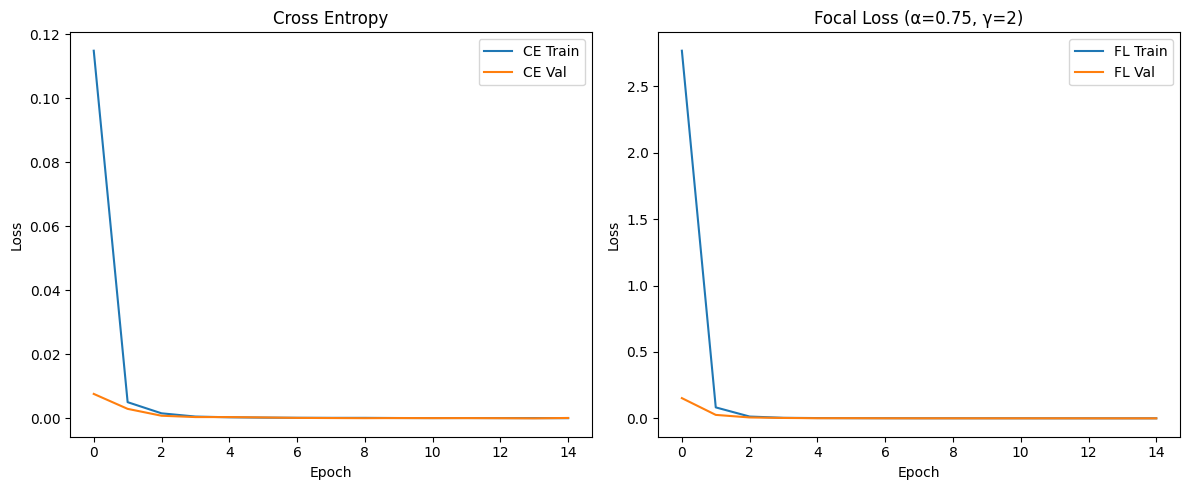


Cross Entropy Model Predictions


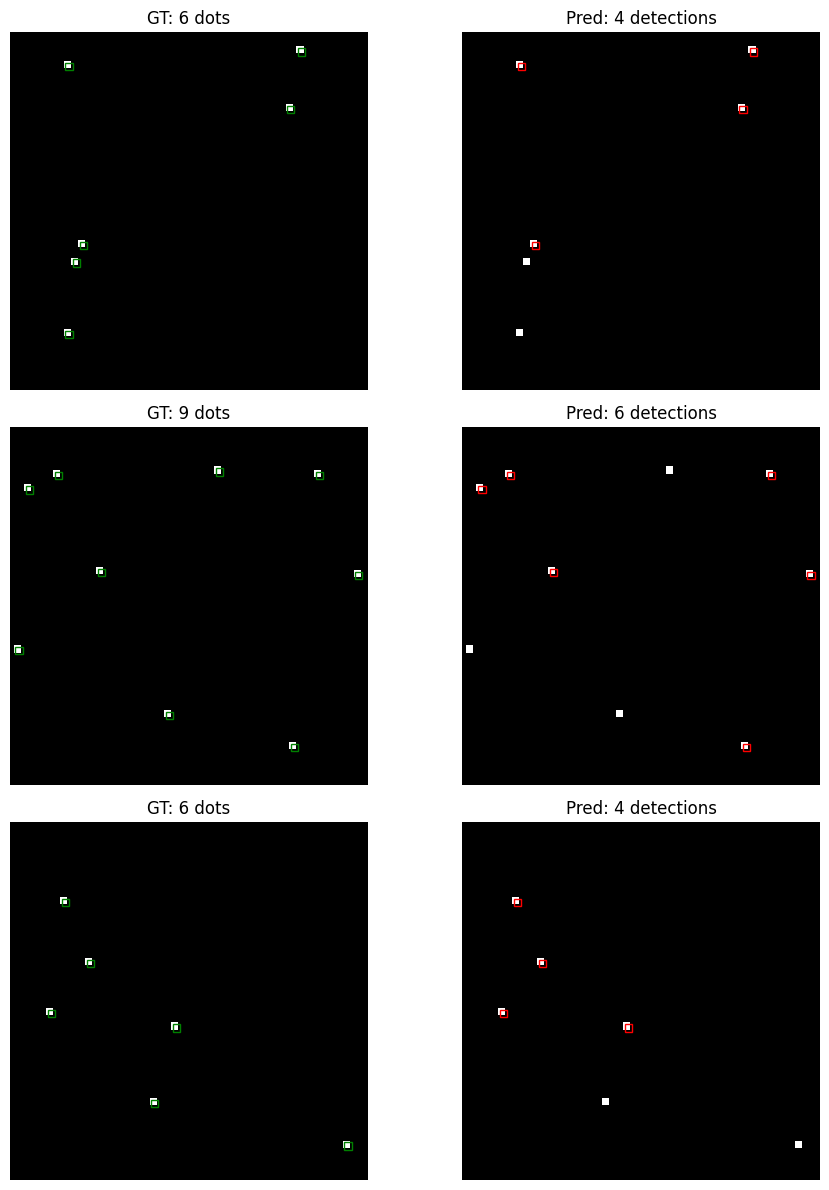


Focal Loss Model Predictions


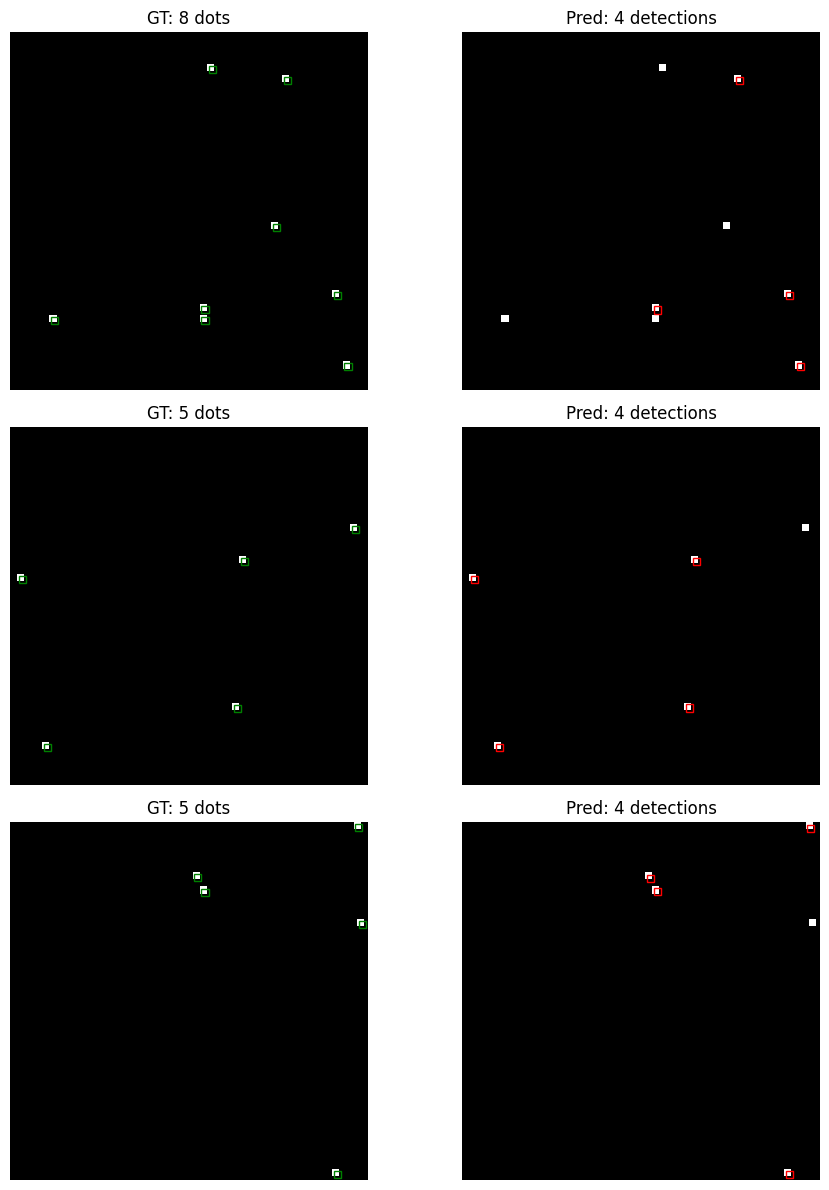


Mean IoU (Cross Entropy): 0.7043
Mean IoU (Focal Loss):   0.7217


In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_ce, label='CE Train')
plt.plot(val_ce, label='CE Val')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Cross Entropy'); plt.legend()
plt.subplot(1,2,2)
plt.plot(train_fl, label='FL Train')
plt.plot(val_fl, label='FL Val')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Focal Loss (α=0.75, γ=2)'); plt.legend()
plt.tight_layout()
plt.show()

def decode_predictions(cls_logits, reg_pred, anchors, conf_thresh=0.5):
    anchors = anchors.to(cls_logits.device)
    probs = F.softmax(cls_logits, dim=1)[:, 1]  
    mask = probs > conf_thresh
    if not mask.any():
        return [], []
    selected_anchors = anchors[mask]
    selected_reg = reg_pred[mask]
    selected_probs = probs[mask]

    cx = selected_anchors[:,0] + selected_reg[:,0] * selected_anchors[:,2]
    cy = selected_anchors[:,1] + selected_reg[:,1] * selected_anchors[:,3]
    w = selected_anchors[:,2] * torch.exp(selected_reg[:,2])
    h = selected_anchors[:,3] * torch.exp(selected_reg[:,3])
    boxes = torch.stack([cx - w/2, cy - h/2, cx + w/2, cy + h/2], dim=1)
    return boxes, selected_probs

def nms(boxes, scores, iou_threshold=0.4):
    if len(boxes) == 0:
        return torch.tensor([], dtype=torch.long)
    order = scores.argsort(descending=True)
    keep = []
    while order.size(0) > 0:
        i = order[0]
        keep.append(i)
        if order.size(0) == 1:
            break
        xx1 = torch.max(boxes[i,0], boxes[order[1:],0])
        yy1 = torch.max(boxes[i,1], boxes[order[1:],1])
        xx2 = torch.min(boxes[i,2], boxes[order[1:],2])
        yy2 = torch.min(boxes[i,3], boxes[order[1:],3])
        inter = (xx2-xx1).clamp(min=0) * (yy2-yy1).clamp(min=0)
        area_i = (boxes[i,2]-boxes[i,0])*(boxes[i,3]-boxes[i,1])
        area_j = (boxes[order[1:],2]-boxes[order[1:],0])*(boxes[order[1:],3]-boxes[order[1:],1])
        iou = inter / (area_i + area_j - inter + 1e-7)
        order = order[1:][iou <= iou_threshold]
    return torch.tensor(keep, dtype=torch.long)

def visualize_predictions(model, val_loader, device, num_samples=3, conf_thresh=0.5):
    model.eval()
    images, targets = next(iter(val_loader))
    images = images[:num_samples].to(device)
    cls_pred, reg_pred = model(images)
    anchors = model.anchors.to(device)
    fig, axes = plt.subplots(num_samples, 2, figsize=(10, 4*num_samples))
    for i in range(num_samples):
        img = images[i,0].cpu().numpy()
        gt_boxes = targets[i].cpu().numpy()
        
        axes[i,0].imshow(img, cmap='gray')
        for box in gt_boxes:
            cx, cy, w, h = box
            x1 = (cx - w/2) * 100
            y1 = (cy - h/2) * 100
            rect = plt.Rectangle((x1, y1), w*100, h*100, linewidth=1, edgecolor='g', facecolor='none')
            axes[i,0].add_patch(rect)
        axes[i,0].set_title(f"GT: {len(gt_boxes)} dots")
        axes[i,0].axis('off')
        
        boxes, scores = decode_predictions(cls_pred[i], reg_pred[i], anchors, conf_thresh)
        if len(boxes) > 0:
            keep = nms(boxes.cpu(), scores.cpu())
            boxes = boxes[keep]   
        axes[i,1].imshow(img, cmap='gray')
        for box in boxes:
            x1, y1, x2, y2 = box.detach().cpu().numpy() * 100
            rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=1, edgecolor='r', facecolor='none')
            axes[i,1].add_patch(rect)
        axes[i,1].set_title(f"Pred: {len(boxes)} detections")
        axes[i,1].axis('off')
    plt.tight_layout()
    plt.show()
    
print("\nCross Entropy Model Predictions")
visualize_predictions(model_ce, val_loader, device, num_samples=3)

print("\nFocal Loss Model Predictions")
visualize_predictions(model_fl, val_loader, device, num_samples=3)

def evaluate_iou(model, val_loader, device, conf_thresh=0.5, nms_iou=0.4):
    model.eval()
    all_ious = []
    with torch.no_grad():
        for images, targets in val_loader:
            images = images.to(device)
            cls_pred, reg_pred = model(images)
            for i in range(images.size(0)):
                gt = targets[i].cpu().numpy()
                if len(gt) == 0:
                    continue
                boxes, scores = decode_predictions(cls_pred[i], reg_pred[i], model.anchors.to(device), conf_thresh)
                if len(boxes) == 0:
                    continue
                keep = nms(boxes.cpu(), scores.cpu(), nms_iou)
                boxes = boxes[keep].cpu().numpy()
                for gt_box in gt:
                    gx1 = (gt_box[0] - gt_box[2]/2)*100
                    gy1 = (gt_box[1] - gt_box[3]/2)*100
                    gx2 = (gt_box[0] + gt_box[2]/2)*100
                    gy2 = (gt_box[1] + gt_box[3]/2)*100
                    best_iou = 0
                    for pred_box in boxes:
                        px1, py1, px2, py2 = pred_box*100
                        ix1 = max(gx1, px1); iy1 = max(gy1, py1)
                        ix2 = min(gx2, px2); iy2 = min(gy2, py2)
                        if ix2 > ix1 and iy2 > iy1:
                            inter = (ix2-ix1)*(iy2-iy1)
                            area_g = (gx2-gx1)*(gy2-gy1)
                            area_p = (px2-px1)*(py2-py1)
                            iou = inter / (area_g + area_p - inter)
                            best_iou = max(best_iou, iou)
                    all_ious.append(best_iou)
    return np.mean(all_ious) if all_ious else 0

miou_ce = evaluate_iou(model_ce, val_loader, device)
miou_fl = evaluate_iou(model_fl, val_loader, device)
print(f"\nMean IoU (Cross Entropy): {miou_ce:.4f}")
print(f"Mean IoU (Focal Loss):   {miou_fl:.4f}")

## Analysis

So in my SSD model, I have used 3 different anchor box sizes. These sizes were selected to be close to the 2 by 2 squares. in each image there is between 5 and 10 of these squares. 

The problem in predictors like YoLo and SSD is that there are many negative samples for each positive sample, So the model will conveniently predict negative for each anchor box provided to it during inference. To fix this problem we have several ways, for one we can increase the weight of positive class loss in these situations. The other solution is to use focal loss. This loss can be formulated as : $-\alpha_{t}(1-p_{t})^\gamma\log(p_{t})$. So in this formula if we set $\gamma$ to 0 and $\alpha_{t}$ to 1 it will be the same as standard CCE loss. 

$\gamma$ is called the focusing parameter. With easy examples $p_{t}$ is close to 1 and so $1-p_{t}$ will be close to 0. Now when we take this to the power of $\gamma$, relative to $\gamma$ the effect of this value is decreased. This means if $1-p_{t}$ is smaller meaning the model is more confident it will have much less contribution to the loss compared to examples where the model is not confident.

$\alpha$ on the other hand acts more like the weight used in imbalanced classes to increase the effect of the minority class.

In the training curves, the starting value for CCE and all the respective values are extremely low, Now we know this loss is mainly contributed from the positive class meaning in CCE the effect of the minority class is not amplified. In focal loss the starting value and all the other values are substantially more.

## Notice
Again I have used AI for writing the visualization and training code, but all the other parts are written by myself.